
# 01 - Chimeric Inspection (PXD037527)

Load all `psm.tsv` files (FragPipe) from sets 02ng_30m_12mz/fragpipe_mbr and 1.6-48mz_30m/fragpipe,
count PSMs per spectrum and estimate chimericity (≥2 PSMs per spectrum).


In [29]:

import pandas as pd
from pathlib import Path
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


In [30]:

# Config: include 02ng_30m_12mz/fragpipe_mbr and 1.6-48mz_30m/fragpipe
# Use absolute path to avoid cwd issues
ROOT = Path('/Users/aminborqal/Documents/Uantwerpen/Research Internship/phase1/PXD037527')
BASES = [
    ROOT / '02ng_30m_12mz' / 'fragpipe_mbr',
    ROOT / '1.6-48mz_30m' / 'fragpipe'
]
psm_files = []
for b in BASES:
    if b.exists():
        psm_files.extend(sorted(b.rglob('psm.tsv')))
    else:
        print(f"Missing base: {b}")
print(f"Found {len(psm_files)} psm.tsv files")


Found 87 psm.tsv files


In [31]:

# Load and concatenate
cols_keep = [
    'Spectrum','Peptide','Charge','Hyperscore','Purity','Intensity',
    'SpectralSim','RTScore','Expectation','Nextscore',
    'Protein','Gene','Protein Description'
]

frames = []
for p in psm_files:
    df = pd.read_csv(p, sep='	')
    df['run'] = Path(p).parent.name
    frames.append(df)

if len(frames) == 0:
    raise ValueError("No psm.tsv files found. Check BASES paths.")

psm = pd.concat(frames, ignore_index=True)
print(psm.shape)


/var/folders/r4/hh357kg10tl7tyxysctqkm100000gn/T/ipykernel_18660/2040237644.py:10: DtypeWarning: Columns (37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(p, sep='	')


(2246503, 40)


In [32]:

# Select only present columns (avoid duplicates)
psm = psm.loc[:, ~psm.columns.duplicated()]
cols_sel = [c for c in cols_keep if c in psm.columns] + ['run']
if 'Spectrum' in psm.columns:
    cols_sel.append('Spectrum')
psm = psm.loc[:, cols_sel]
psm.head()


,Spectrum,Peptide,Charge,Hyperscore,Purity,Intensity,SpectralSim,RTScore,Expectation,Nextscore,Protein,Gene,Protein Description,run,Spectrum
0,Ex_AuLC1_30m_2D19_3_20um30cm_SPE50_15118120_OT...,HAVSEGTK,2,24.5576,0.0,820013.60,0.9802,0.1229,0.000071,24.5576,sp|O60814|H2B1K_HUMAN,H2BC12,Histone H2B type 1-K,02ngK5_1,Ex_AuLC1_30m_2D19_3_20um30cm_SPE50_15118120_OT...
1,Ex_AuLC1_30m_2D19_3_20um30cm_SPE50_15118120_OT...,HAVSEGTK,2,22.7800,0.0,645029.56,0.9483,0.1539,0.000418,22.7800,sp|O60814|H2B1K_HUMAN,H2BC12,Histone H2B type 1-K,02ngK5_1,Ex_AuLC1_30m_2D19_3_20um30cm_SPE50_15118120_OT...
2,Ex_AuLC1_30m_2D19_3_20um30cm_SPE50_15118120_OT...,HAVSEGTK,2,15.7807,0.0,812365.80,0.8095,0.1889,0.458086,15.7807,sp|O60814|H2B1K_HUMAN,H2BC12,Histone H2B type 1-K,02ngK5_1,Ex_AuLC1_30m_2D19_3_20um30cm_SPE50_15118120_OT...
3,Ex_AuLC1_30m_2D19_3_20um30cm_SPE50_15118120_OT...,HAVSEGTK,2,11.7465,0.0,790822.00,0.7724,0.2803,25.881600,11.7465,sp|O60814|H2B1K_HUMAN,H2BC12,Histone H2B type 1-K,02ngK5_1,Ex_AuLC1_30m_2D19_3_20um30cm_SPE50_15118120_OT...
4,Ex_AuLC1_30m_2D19_3_20um30cm_SPE50_15118120_OT...,EDTEEHHLR,3,11.2393,0.0,0.00,0.6858,1.5295,42.979740,11.2393,sp|P22626|ROA2_HUMAN,HNRNPA2B1,Heterogeneous nuclear ribonucleoproteins A2/B1,02ngK5_1,Ex_AuLC1_30m_2D19_3_20um30cm_SPE50_15118120_OT...


In [33]:
# Remove duplicate columns
psm = psm.loc[:, ~psm.columns.duplicated()]

print("Columns after removing duplicates:")
print(psm.columns.tolist())
print(f"Number of columns: {len(psm.columns)}")

# Now run the chimeric analysis
spec_counts = psm.groupby('Spectrum').size()
print(f"\nTotal spectra: {spec_counts.shape[0]}")
print(f"Chimeric spectra (>=2 PSM): {(spec_counts>=2).sum()}")
print(f"Spectra with >=3 PSM: {(spec_counts>=3).sum()}")
print(f"Spectra with >=4 PSM: {(spec_counts>=4).sum()}")
print(f"Spectra with >=5 PSM: {(spec_counts>=5).sum()}")

max_psm = spec_counts.max()
dist = spec_counts.value_counts().sort_index()
dist_full = dist.reindex(range(1, max_psm+1), fill_value=0)

print("\nPSM distribution per spectrum (1..max):")
print(dist_full)

Columns after removing duplicates:
['Spectrum', 'Peptide', 'Charge', 'Hyperscore', 'Purity', 'Intensity', 'SpectralSim', 'RTScore', 'Expectation', 'Nextscore', 'Protein', 'Gene', 'Protein Description', 'run']
Number of columns: 14

Total spectra: 1121125
Chimeric spectra (>=2 PSM): 651616
Spectra with >=3 PSM: 281366
Spectra with >=4 PSM: 136924
Spectra with >=5 PSM: 34408

PSM distribution per spectrum (1..max):
1     469509
2     370250
3     144442
4     102516
5      19368
6      12197
7        260
8       2263
9         42
10       278
Name: count, dtype: int64


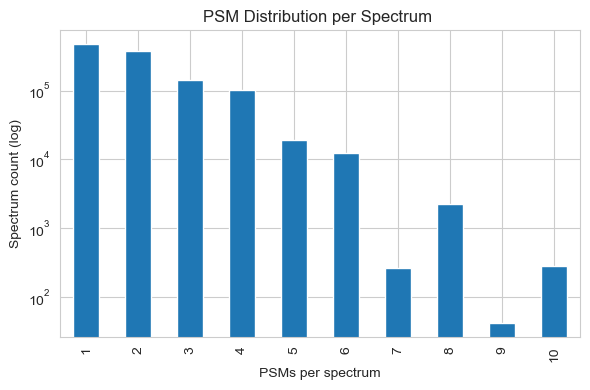

In [35]:

# Plot PSM distribution per spectrum (log y)
plt.figure(figsize=(6,4))
spec_counts.value_counts().sort_index().plot(kind='bar')
plt.xlabel('PSMs per spectrum')
plt.ylabel('Spectrum count (log)')
plt.yscale('log')
plt.title('PSM Distribution per Spectrum ')
plt.tight_layout()
plt.show()
